In [1]:
import numpy as np
import pandas as pd
from scipy.stats import linregress, pearsonr

from armored.models import *
from armored.preprocessing import *

import itertools

from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt


params = {
    'figure.figsize': (7, 5),       # Figure size in inches
    'figure.dpi': 300,               # Resolution in dots per inch
    'axes.labelsize': 7,            # Font size of the axes labels
    'axes.titlesize': 7,            # Font size of the subplot titles
    'axes.titlepad': 10,             # Spacing between the subplot title and the plot
    'axes.linewidth': .5,           # Width of the axis lines
    'axes.grid': False,              # Display grid lines
    'axes.grid.axis': 'both',        # Display grid lines for both major and minor ticks
    'grid.alpha': 0.5,               # Transparency of the grid lines
    'grid.linewidth': 0.5,           # Width of the grid lines
    'xtick.labelsize': 7,           # Font size of the x-axis tick labels
    'ytick.labelsize': 7,           # Font size of the y-axis tick labels
    'xtick.major.size': 3,           # Length of the major x-axis ticks in points
    'xtick.major.width': .5,        # Width of the major x-axis ticks
    'ytick.major.size': 3,           # Length of the major y-axis ticks in points
    'ytick.major.width': .5,        # Width of the major y-axis ticks
    'xtick.minor.size': 2,           # Length of the minor x-axis ticks in points
    'xtick.minor.width': .5,        # Width of the minor x-axis ticks
    'ytick.minor.size': 2,           # Length of the minor y-axis ticks in points
    'ytick.minor.width': .5,        # Width of the minor y-axis ticks
    'xtick.direction': 'in',         # Direction of the x-axis ticks ('in', 'out', or 'inout')
    'ytick.direction': 'in',         # Direction of the y-axis ticks ('in', 'out', or 'inout')
    'legend.fontsize': 7,           # Font size of the legend
    'legend.frameon': True,          # Whether to draw a frame around the legend
    'legend.facecolor': 'inherit',   # Background color of the legend
    'legend.edgecolor': '0.8',       # Edge color of the legend
    'legend.framealpha': 0.8,        # Transparency of the legend frame
    'legend.loc': 'best',            # Location of the legend ('best', 'upper right', 'upper left', 'lower left', etc.)
    'legend.title_fontsize': 7,     # Font size of the legend title
    'svg.fonttype': 'none'           # Output font type for PDF files
}

plt.rcParams.update(params)

In [2]:
species = ['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs', 'CHabs',
           'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs', 'RIabs']
metabolites = ['pH', 'Lactate', 'Butyrate', 'Acetate']
controls = ['AcGum', 'ArGal', 'Inulin', 'Pectin', 'Starch', 'Xylan']

# concatenate all observed and all system variables 
observed = np.concatenate((np.array(species), np.array(metabolites)))
system_variables = np.concatenate((np.array(species), np.array(metabolites), np.array(controls)))

# names of variables
design_vars = [s + " meas" for s in species] + controls

In [3]:
# predictions and measurements for sampled conditions
pred_df = pd.read_csv("space/sampled_space.csv")

# experimental data
E = []
X = []
y_meas = []
y_pred = []
for exp, df_exp in pred_df.groupby('Experiments'):
    
    # experimental condition
    E.append(exp)
    X.append(df_exp[design_vars].values[0])

    # predicted objective
    y_pred.append(df_exp['Objective pred'].values[-1])
    
    # sometimes measured objective is nan
    if ~np.isnan(df_exp['Objective meas'].values[-1]):
        y_meas.append(df_exp['Objective meas'].values[-1])
    else:
        y_meas.append(np.nan)
        
E = np.array(E)
X = np.array(np.array(X)>0, int)
y_meas = np.array(y_meas)
y_pred = np.array(y_pred)

In [4]:
# data with initial and end point measurements
df_exp0 = pd.read_csv("data/exp0/exp0_metabolites.csv")
df_exp1 = pd.read_csv("data/exp1/exp1_metabolites.csv")
df_exp2 = pd.read_csv("data/exp2/exp2_metabolites.csv")
df_exp3 = pd.read_csv("data/exp3/exp3_metabolites.csv")
df_exp4a = pd.read_csv("data/exp4/exp4_metabolites_best_reps.csv")

exp_names_reps = [e+"-rep" for e in df_exp4a.Experiments.values]
df_exp4a['Experiments'] = exp_names_reps

df_exp4b = pd.read_csv("data/exp4/exp4_metabolites_new_best.csv")

E0 = []
for exp, df_exp in df_exp0.groupby('Experiments'):
    E0.append(exp)
    
E1 = []
for exp, df_exp in df_exp1.groupby('Experiments'):
    E1.append(exp)

E2 = []
for exp, df_exp in df_exp2.groupby('Experiments'):
    E2.append(exp)
    
E3 = []
for exp, df_exp in df_exp3.groupby('Experiments'):
    E3.append(exp)
    
E3val = []
for exp, df_exp in df_exp4a.groupby('Experiments'):
    E3val.append(exp)
    
E4 = []
for exp, df_exp in df_exp4b.groupby('Experiments'):
    E4.append(exp)

In [5]:
# E = np.append(E, E_sim)
# X = np.concatenate((X, X_sim), axis=0)
# y = np.append(y_pred, y_sim)

# Dimensionality reduction of design space

In [6]:
# species phylogenetic tree 
tree = ({'ER'}, 
        {'RI'},
        {'CC'}, 
        {'BH'}, 
        {'DF'},
        {'AC'},
        {'FP'},
        {'CH'}, 
        {'CA'}, 
        {'EL'}, 
        {'BA'},
        {'BL'}, 
        {'PJ'}, 
        {'BU'},
        {'PC'},
        {'ER', 'RI'}, 
        {'BH', 'DF'},
        {'CA', 'EL'}, 
        {'BA', 'BL'}, 
        {'BU', 'PC'},
        {'ER', 'RI', 'CC'},
        {'PJ', 'BU', 'PC'},
        {'CA', 'EL', 'BA', 'BL'},
        {'ER', 'RI', 'CC', 'BH', 'DF'},
        {'ER', 'RI', 'CC', 'BH', 'DF', 'AC'},
        {'ER', 'RI', 'CC', 'BH', 'DF', 'AC', 'FP'},
        {'ER', 'RI', 'CC', 'BH', 'DF', 'AC', 'FP', 'CH'},
        {'ER', 'RI', 'CC', 'BH', 'DF', 'AC', 'FP', 'CH', 'CA', 'EL', 'BA', 'BL'})

In [7]:
# vectorize phylogenetic information
Z = np.zeros([len(E), len(tree)])

# experiment name defines species and fiber presence 
for i, exp in enumerate(E):
    for j, node in enumerate(tree):
        # if np.any(np.in1d(list(node), exp.split('-'))):
        # if there's a non-empty intersection 
        if bool(set(node) & set(exp.split('-'))):
            Z[i, j] = 1.

# concatenate phylogentic information with fiber information
M = np.concatenate((Z, X[:,-6:]), -1)

In [8]:
M.shape

(1193, 34)

In [9]:
# try MDS
from sklearn.manifold import MDS

# init and fit
mds = MDS(n_components=2, dissimilarity='euclidean', random_state=8)
Y = mds.fit_transform(M)

# Compute the Gram matrix B = -0.5 * H * D^2 * H
D = mds.dissimilarity_matrix_
n = D.shape[0]
H = np.eye(n) - np.ones((n, n)) / n  # Centering matrix
D_squared = D ** 2
B = -0.5 * H @ D_squared @ H

# Perform eigenvalue decomposition on the Gram matrix
eigenvalues, _ = np.linalg.eigh(B)  # eigh() returns sorted eigenvalues

# Sort eigenvalues in descending order
eigenvalues = np.flip(eigenvalues)

# Compute the percent variance explained by the first 2 components
total_variance = np.sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance

In [10]:
# # dictionary of labels
# labels = {'AC-BA-BH-BL-BU-CC-CH-DF-ER-RI-5Inulin-1Pectin':'i',
#           'AC-BA-BH-BL-BU-CH-DF-ER-RI-4Inulin-1Pectin-1Starch':'ii',
#           'AC-BA-BH-BL-BU-CH-DF-FP-RI-4Inulin-1Pectin-1Xylan':'iii',
#           'AC-BA-BH-BL-BU-CH-DF-ER-FP-RI-4Inulin-1Pectin-1Xylan':'iv',
#           'AC-BA-BL-BU-CC-CH-DF-ER-FP-RI-4Inulin-1Pectin-1Xylan':'v',
#           'AC-BL-PJ-AcGum':'vi',
#           'BA-BL-CC-CH-DF-ER-FP-PC-Xylan':'vii',
#           'BA-BH-BL-BU-CC-FP-PC-Starch':'viii', 
#           'BA-BU-CA-CC-CH-EL-PC-PJ-Starch':'ix'}

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Function to compute WCSS for different values of k
def elbow_method(M, max_k=10, random_state=42):
    """
    Apply the elbow method to determine the optimal number of clusters.

    Parameters:
        M (ndarray): The data matrix of shape (n_samples, n_features).
        max_k (int): The maximum number of clusters to consider.
        random_state (int): Random seed for reproducibility.

    Returns:
        wcss (list): List of WCSS values for each k.
    """
    # Standardize the data to improve k-means performance
    scaler = StandardScaler()
    M_scaled = scaler.fit_transform(M)

    wcss = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=random_state)
        kmeans.fit(M_scaled)
        wcss.append(kmeans.inertia_)

    return wcss

# Plotting the elbow method
def plot_elbow(wcss, max_k):
    """
    Plot the elbow curve to visualize the WCSS values.

    Parameters:
        wcss (list): List of WCSS values.
        max_k (int): Maximum number of clusters considered.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
    plt.title('Elbow Method for Optimal k')
    plt.xticks(range(1, max_k + 1))
    plt.grid()
    plt.show()

In [12]:
M.shape

(1193, 34)

In [13]:
Y.shape

(1193, 2)

/home/jaron/.venvs/base/lib/python3.12/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (28) found smaller than n_clusters (29). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/jaron/.venvs/base/lib/python3.12/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (29) found smaller than n_clusters (30). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


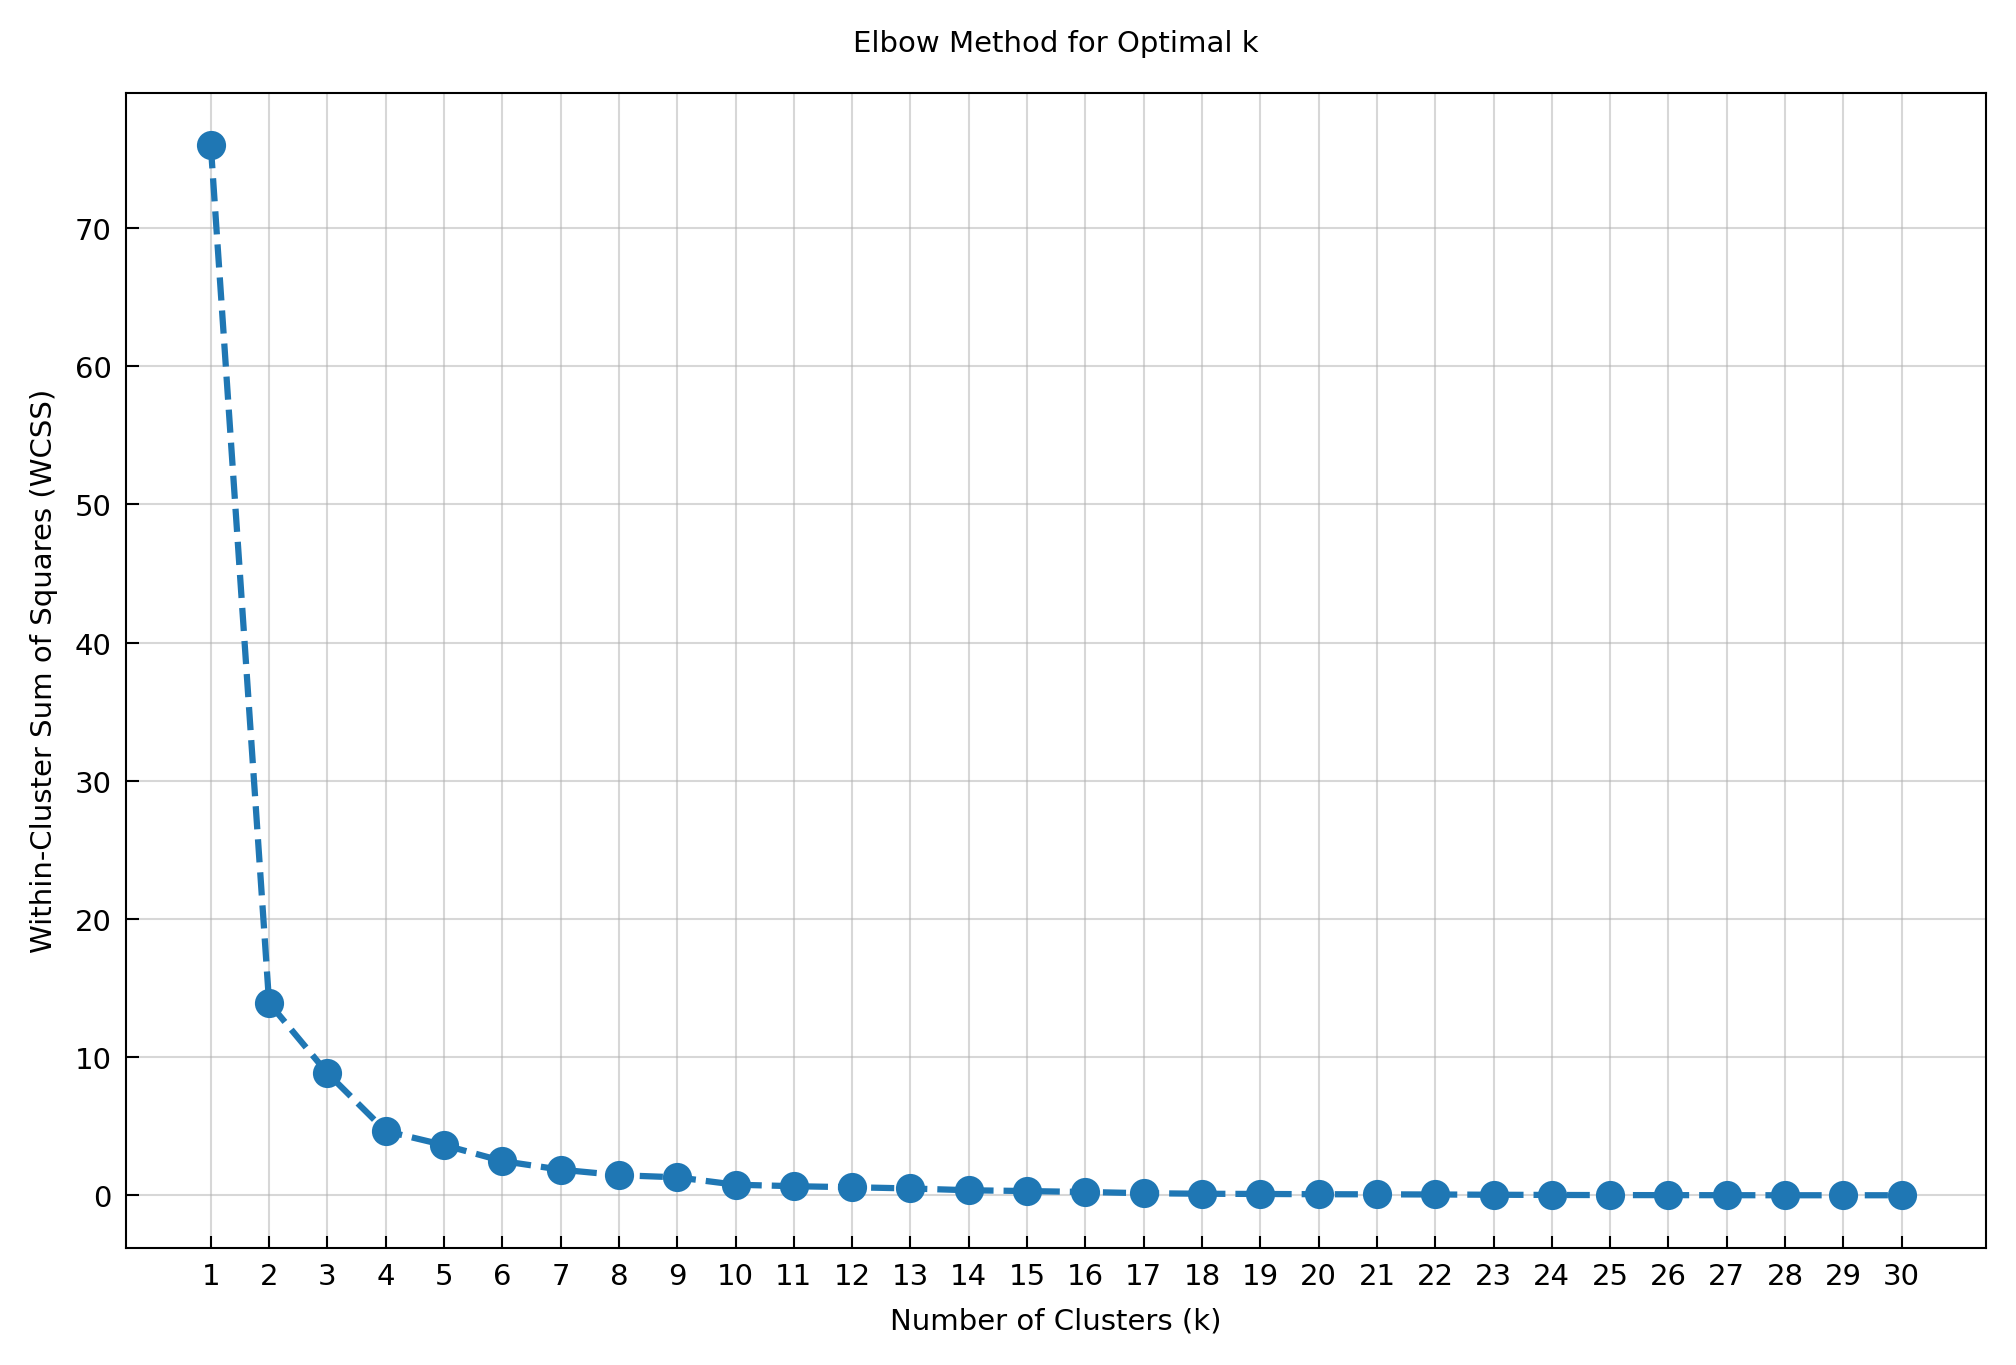

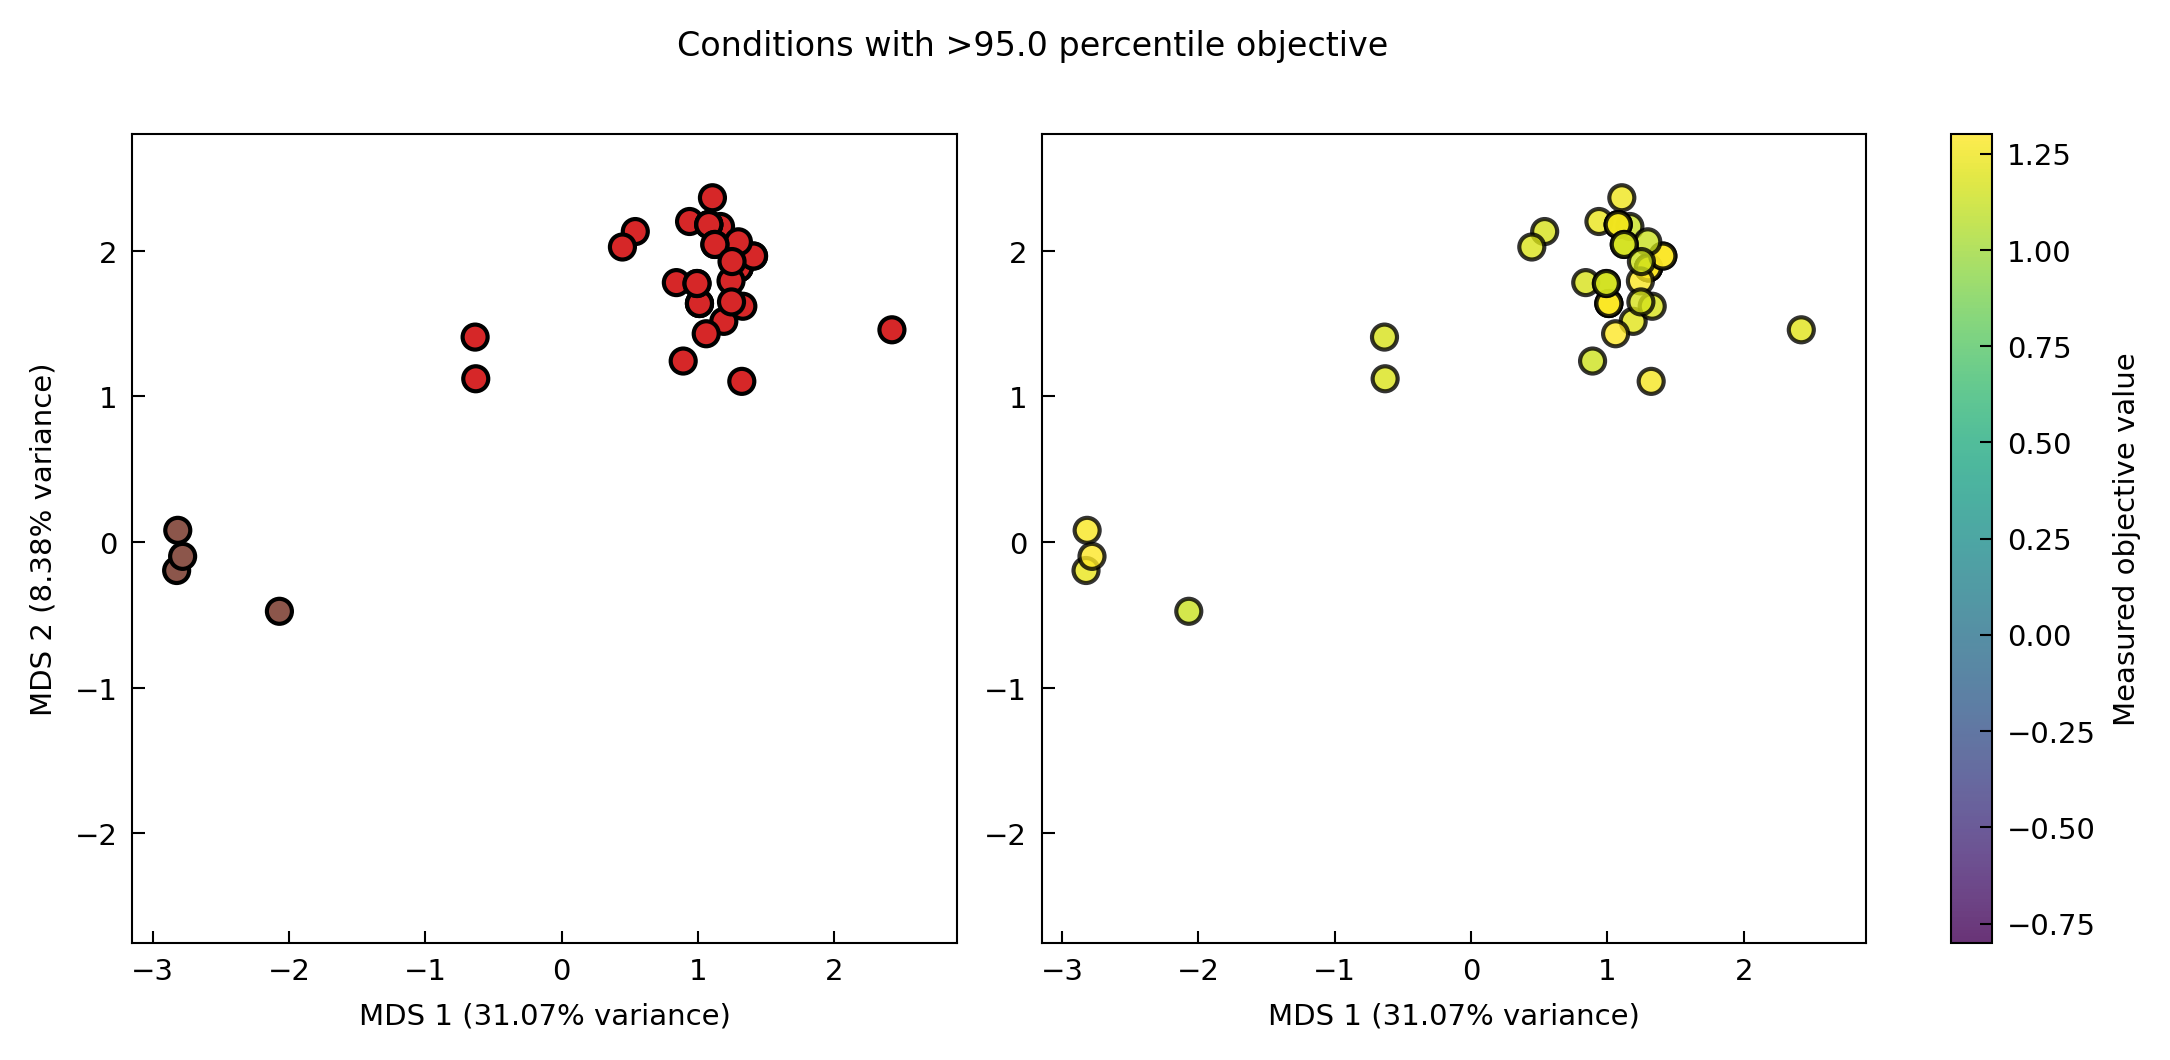

/home/jaron/.venvs/base/lib/python3.12/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (6) found smaller than n_clusters (7). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/jaron/.venvs/base/lib/python3.12/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (6) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


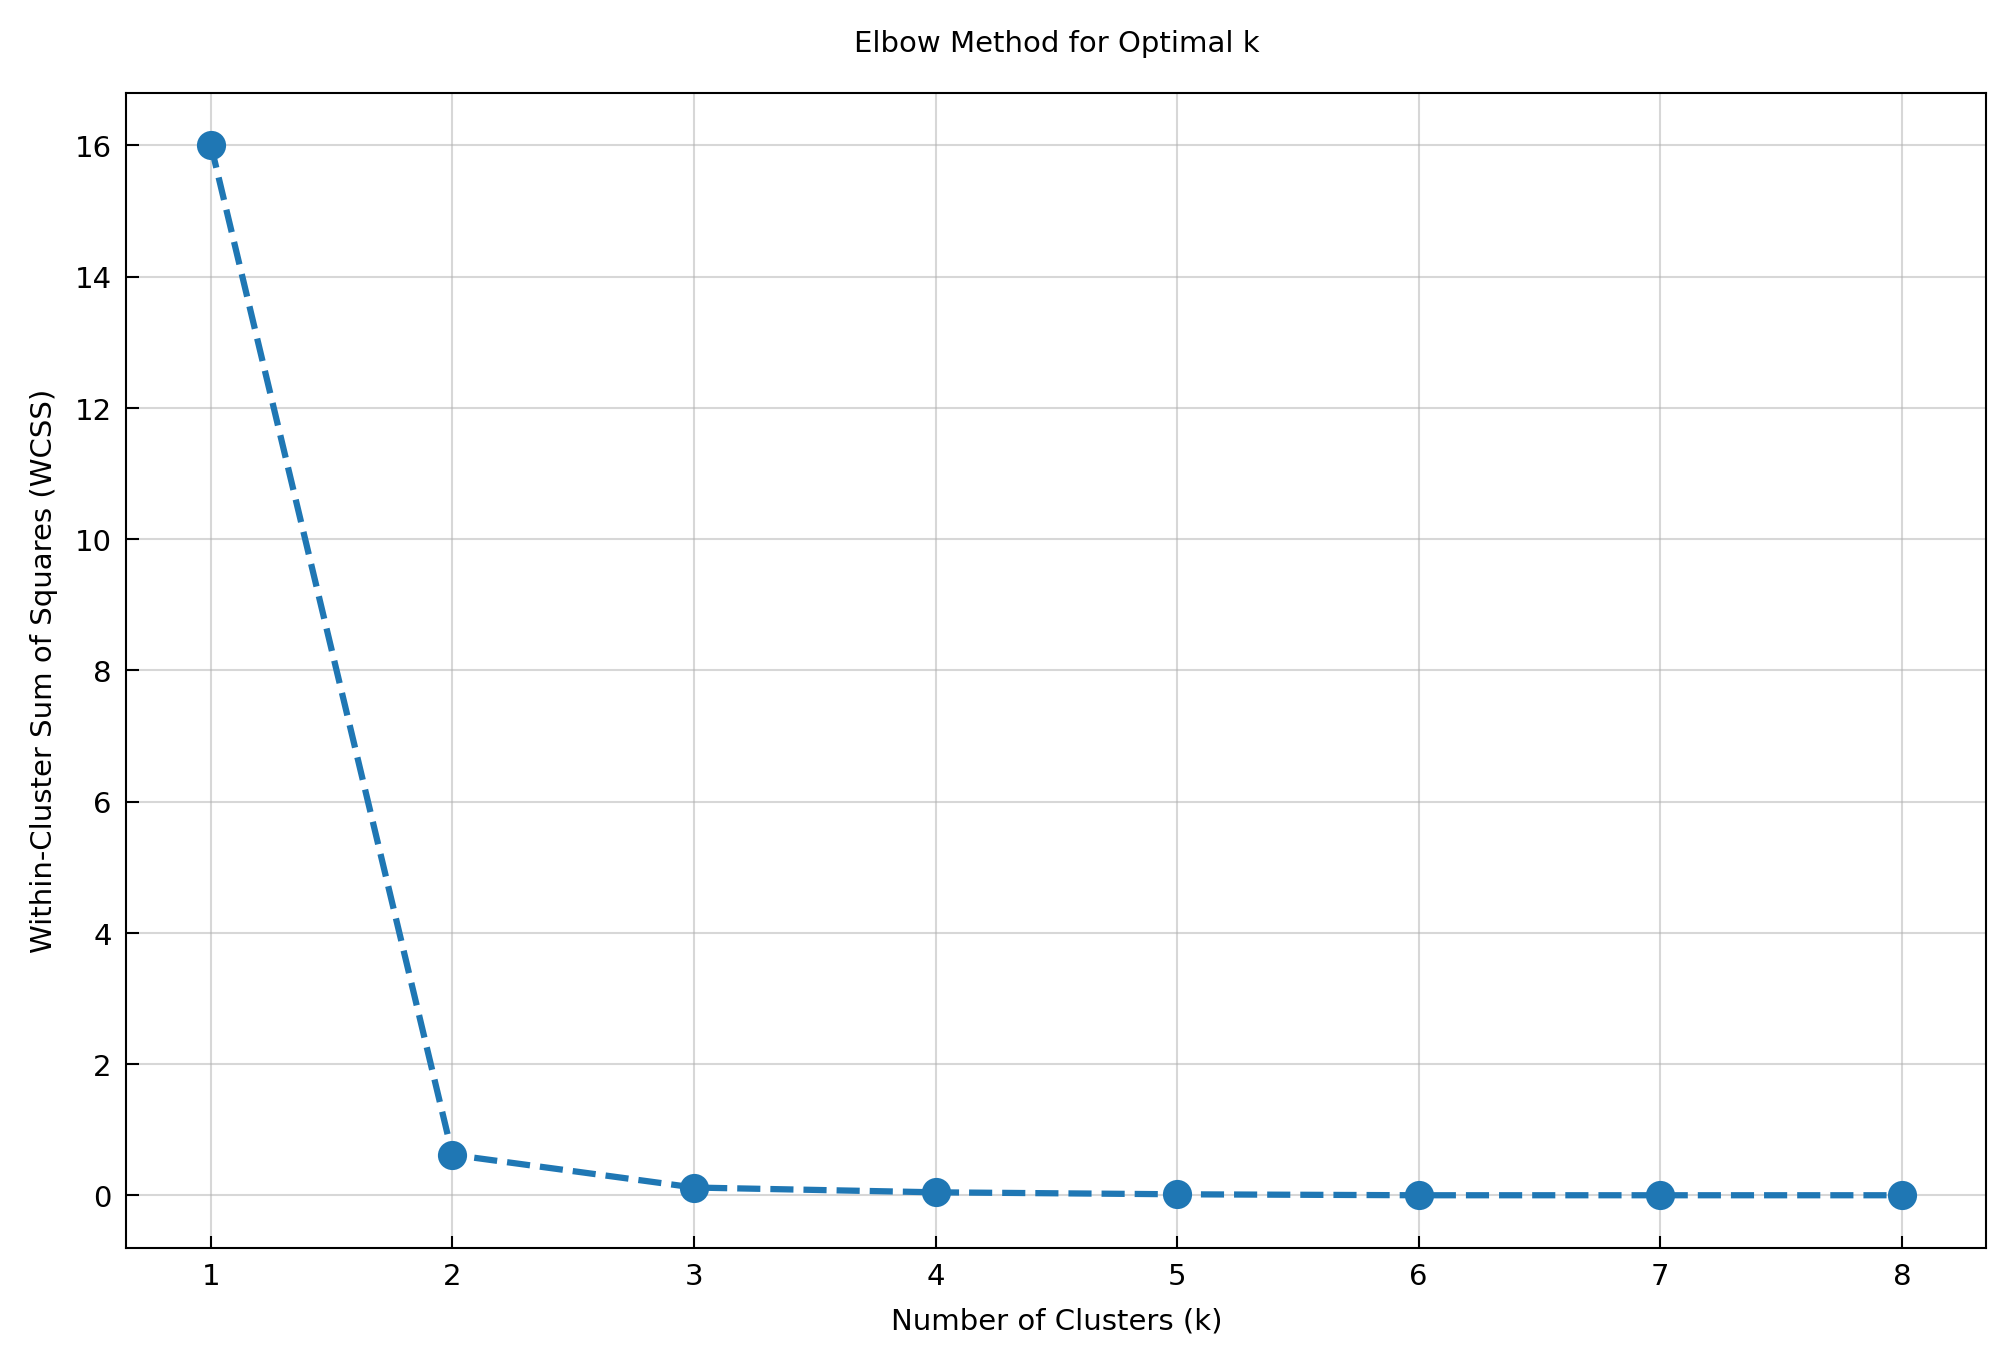

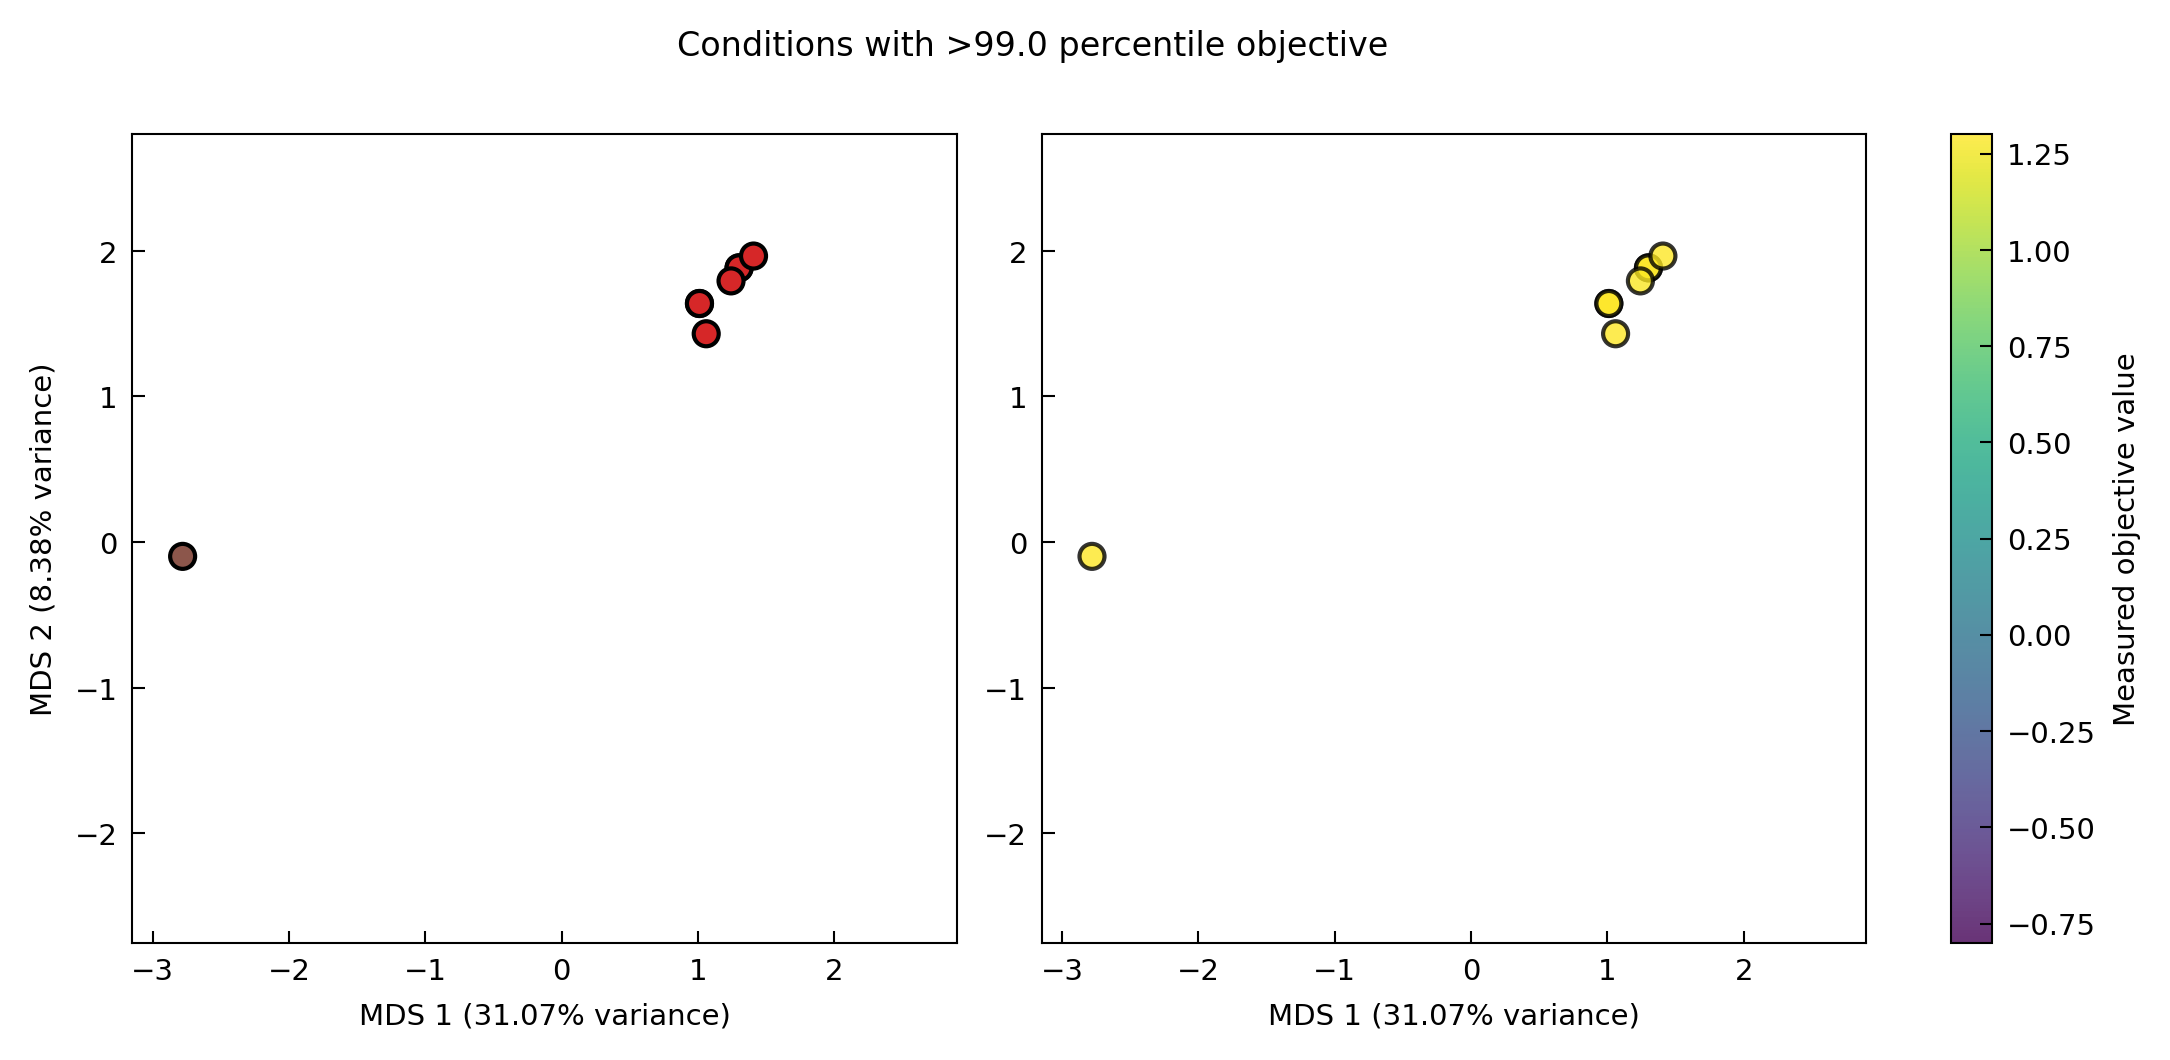

In [23]:
quantiles = [.95, .99]
n_clusters_q = [2, 2]
for i, quantile in enumerate(np.nanquantile(y_meas, quantiles)):
    q_idx = y_meas >= quantile
    
    # Compute WCSS for each k 
    max_k = min([30, sum(q_idx)])
    wcss = elbow_method(Y[q_idx], max_k=max_k)

    # Plot the elbow curve
    plot_elbow(wcss, max_k)

    # plot showing traversal through design space
    fig = plt.figure(figsize=(8, 3.5))

    # Define a 1-row, 3-column grid, with the last column reserved for the colorbar
    gs = GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.15)

    # dtl progression
    ax1 = fig.add_subplot(gs[0, 0])

    ### perform Kmeans clustering on the subset of data in quantile ### 

    # Standardize the data to improve k-means performance
    scaler = StandardScaler()
    Y_scaled = scaler.fit_transform(Y[q_idx])

    # fit kmeans model
    kmeans = KMeans(n_clusters=n_clusters_q[i], random_state=21, n_init="auto").fit(Y_scaled)
    k_vals = kmeans.labels_

    # scatter plot with Kmeans clusters
    color_dict = {0: 3, 1: 5}
    k_colors = [f"C{color_dict[k]}" for k in k_vals]
    ax1.scatter(Y[q_idx, 0], Y[q_idx, 1], c=k_colors, edgecolor='k')

    # Add explained variance information to axis labels
    # ax1.legend() # (ncol=2, loc='upper left')
    ax1.set_xlabel(f'MDS 1 ({explained_variance_ratio[0]:.2%} variance)')
    ax1.set_ylabel(f'MDS 2 ({explained_variance_ratio[1]:.2%} variance)')
    ax1.set_xlim([-3.15, 2.9])
    ax1.set_ylim([-2.75, 2.8])

    # objective
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_xlim([-3.15, 2.9])
    ax2.set_ylim([-2.75, 2.8])
    
    # scatter plot of embedding 
    sc = ax2.scatter(Y[q_idx, 0], Y[q_idx, 1], c=y_meas[q_idx], vmin=-.8, vmax=1.3, cmap='viridis', edgecolor='k', alpha=.8)

    # Add explained variance information to axis labels
    ax2.set_xlabel(f'MDS 1 ({explained_variance_ratio[0]:.2%} variance)')
    # ax2.set_ylabel(f'PCo2 ({explained_variance_ratio[1]:.2%} variance)')

    # Add the colorbar without affecting plot sizes
    cbar = fig.colorbar(sc, cax=fig.add_subplot(gs[0, 2]))
    cbar.set_label('Measured objective value')
    # plt.savefig('figures/landscapes/mds_presence_absence.png', dpi=300)
    # plt.savefig('figures/landscapes/mds_phylogeny_sparse.png', dpi=300)
    # plt.savefig('figures/landscapes/mds_phylogeny_dtl_objective.svg', dpi=300)
    # plt.savefig('figures/landscapes/mds_presence_dtl_objective.png', dpi=300)
    plt.suptitle(f"Conditions with >{quantiles[i]*100} percentile objective", fontsize=8)
    plt.savefig(f"figures/landscapes/mds_reverse_phylogeny_kmeans_objective_{str(100 * quantiles[i]).split('.')[0]}.svg")
    plt.show() 

In [15]:
yticklabels = [s.split("abs")[0] for s in species] + controls

In [16]:
# cluster idx of 99th percentile conditions 
k_99 = np.unique(k_vals)
k_99

array([0, 1], dtype=int32)

In [17]:
# cluster colors
cluster_colors = ['Red', 'Brown']

[1.36320255 1.32604952 1.31237307 1.30260907 1.2968989 ]


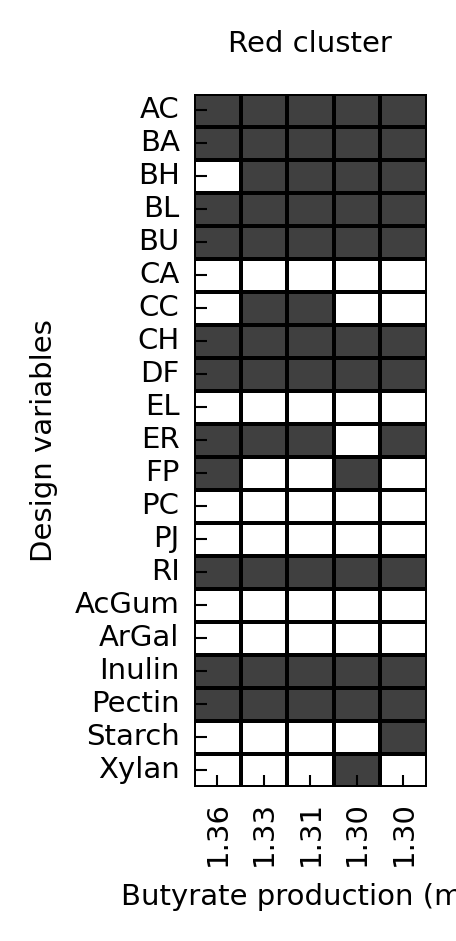

[1.37951727]


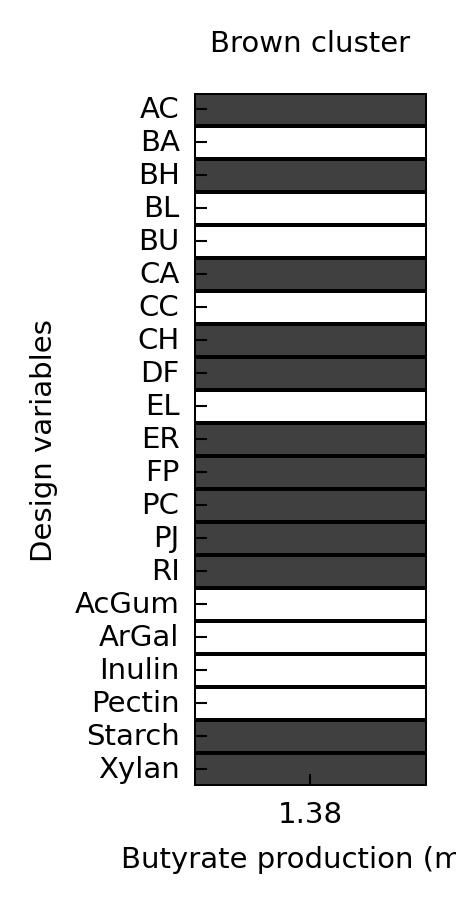

In [18]:
import seaborn as sns

n_show = 5
for i, each_k_99 in enumerate(k_99):
    
    # index of samples in cluster
    cluster_idx = np.isin(k_vals, each_k_99)
    
    # measured values in cluster
    cluster_y_meas = y_meas[q_idx][cluster_idx]
    idx_nan = np.isnan(cluster_y_meas)
    
    # subsample X
    cluster_X = X[q_idx][cluster_idx][~idx_nan]
    
    # sort
    idx_sort = np.argsort(cluster_y_meas[~idx_nan])[::-1]
    print(cluster_y_meas[~idx_nan][idx_sort][:n_show])
    
    # plot heatmap of species/fiber conditions
    plt.figure(figsize=(1, 3))
    sns.heatmap(cluster_X[idx_sort][:n_show].T, 
                cmap="Greys", 
                cbar=False, 
                vmin=0,
                vmax=1.25,
                linewidths=0.5, 
                linecolor='black', 
                xticklabels=[f"{y:.2f}" for y in cluster_y_meas[~idx_nan][idx_sort][:n_show]],
                yticklabels=yticklabels)
    plt.xlabel("Butyrate production (mM)")
    plt.ylabel("Design variables")
    plt.title(f"{cluster_colors[i]} cluster")
    plt.savefig(f"figures/landscapes/kmeans_reverse_{cluster_colors[i]}_cluster.svg")
    plt.show()